<a href="https://colab.research.google.com/github/nirob271/learning-ml-dl-fl/blob/main/numpy_pandas_matplotlib_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install numpy pandas matplotlib

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
data = {
    "Student_ID": [101,102,103,104,105,106,107,108,109,110],
    "Name": ["Asha","Rahim","Karim","Nila","Sami","Tania","Jamal","Rafi","Lina","Ovi"],
    "Math": [78,85,62,90,55,88,73,95,66,80],
    "Physics": [82,79,58,91,60,85,70,96,64,77],
    "Chemistry": [75,83,65,89,57,90,72,94,63,81],
    "Hours_Study": [5,6,3,7,2,6,4,8,3,5],
    "Attendance": [90,95,70,98,60,92,75,99,68,88]
}

df = pd.DataFrame(data)

#Practice Numpy

1. Convert Math, Physics, Chemistry columns into NumPy arrays.
2. Find:
    Mean of each subject
    Max and Min marks

In [33]:
math = df["Math"].to_numpy()
phy = df["Physics"].to_numpy()
chem = df["Chemistry"].to_numpy()

print('Mean Number ==>')
print('Math mean:', np.mean(math))
print('Physics mean:', np.mean(phy))
print('Chemistry mean:', np.mean(chem))

print('\nMax Number ==>')
print('Math max:', np.max(math))
print('Physics max:', np.max(phy))
print('Chemistry max:', np.max(chem))

print('\nMin Number ==>')
print('Math min:', np.min(math))
print('Physics min:', np.min(phy))
print('Chemistry min:', np.min(chem))

Mean Number ==>
Math mean: 77.2
Physics mean: 76.2
Chemistry mean: 76.9

Max Number ==>
Math max: 95
Physics max: 96
Chemistry max: 94

Min Number ==>
Math min: 55
Physics min: 58
Chemistry min: 57


3. Create a new array for Total Marks = Math + Physics + Chemistry

In [34]:
df['total'] = df['Math'] + df['Physics'] + df['Chemistry']
print(df['total'])

0    235
1    247
2    185
3    270
4    172
5    263
6    215
7    285
8    193
9    238
Name: total, dtype: int64


4. Normalize Math marks (0 to 1 scale)

In [35]:
Math_min = np.min(math)
Math_max = np.max(math)


if Math_max - Math_min != 0:
  math_normalized = (math - Math_min) / (Math_max - Math_min)
else:
  math_normalized = np.zeros_like(math)
print(math_normalized)

[0.575 0.75  0.175 0.875 0.    0.825 0.45  1.    0.275 0.625]


#Practice Pandas

1. Add a new column:
Total = Math + Physics + Chemistry
Average = Total / 3

In [49]:
df['Average'] = df['total']/3
df.head()

,Student_ID,Name,Math,Physics,Chemistry,Hours_Study,Attendance,total,Average,Grade
0,101,Asha,78,82,75,5,90,235,78.333333,B
1,102,Rahim,85,79,83,6,95,247,82.333333,B
2,103,Karim,62,58,65,3,70,185,61.666667,C
3,104,Nila,90,91,89,7,98,270,90.000000,A
4,105,Sami,55,60,57,2,60,172,57.333333,C


2. Find top 3 students based on Total marks


In [50]:
top3 = df.sort_values(by='total', ascending=False).head(3)
print(top3)

   Student_ID   Name  Math  Physics  Chemistry  Hours_Study  Attendance  \
7         108   Rafi    95       96         94            8          99   
3         104   Nila    90       91         89            7          98   
5         106  Tania    88       85         90            6          92   

   total    Average Grade  
7    285  95.000000     A  
3    270  90.000000     A  
5    263  87.666667     A  


3. Filter students who: Study > 5 hours AND Attendance > 90

In [51]:
filtered = df[(df['Hours_Study'] > 5) & (df['Attendance'] > 90)]
print(filtered)

   Student_ID   Name  Math  Physics  Chemistry  Hours_Study  Attendance  \
1         102  Rahim    85       79         83            6          95   
3         104   Nila    90       91         89            7          98   
5         106  Tania    88       85         90            6          92   
7         108   Rafi    95       96         94            8          99   

   total    Average Grade  
1    247  82.333333     B  
3    270  90.000000     A  
5    263  87.666667     A  
7    285  95.000000     A  


4. Group students into categories:
A (Average ≥ 85)
B (70–84)
C (< 70)

In [52]:
def grade(Average):
  if Average >= 85:
    return 'A'
  elif Average >= 70:
    return 'B'
  else:
    return 'C'

df['Grade'] = df['Average'].apply(grade)
df[['Name', 'Average' , 'Grade']]


,Name,Average,Grade
0,Asha,78.333333,B
1,Rahim,82.333333,B
2,Karim,61.666667,C
3,Nila,90.000000,A
4,Sami,57.333333,C
5,Tania,87.666667,A
6,Jamal,71.666667,B
7,Rafi,95.000000,A
8,Lina,64.333333,C
9,Ovi,79.333333,B


In [53]:
df["Grade"].value_counts()

,count
Grade,
B,4
C,3
A,3


5. Check missing values (even though dataset has none — practice function)

In [54]:
df.isnull().sum()

,0
Student_ID,0
Name,0
Math,0
Physics,0
Chemistry,0
Hours_Study,0
Attendance,0
total,0
Average,0
Grade,0


#Practice Matplotlib

1. Bar Chart — Math marks of all students

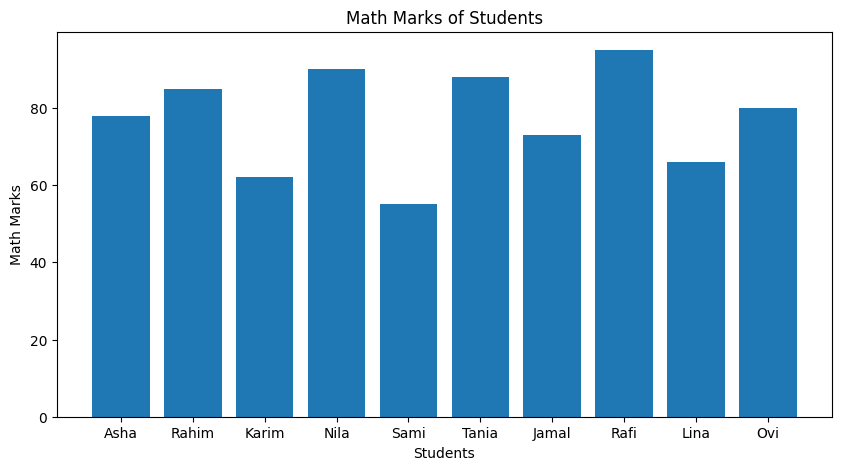

In [47]:
plt.figure(figsize=(10,5))
plt.bar(df["Name"], df["Math"])
plt.title("Math Marks of Students")
plt.xlabel("Students")
plt.ylabel("Math Marks")
plt.show()

2. Line Plot — Hours of Study vs Average Marks

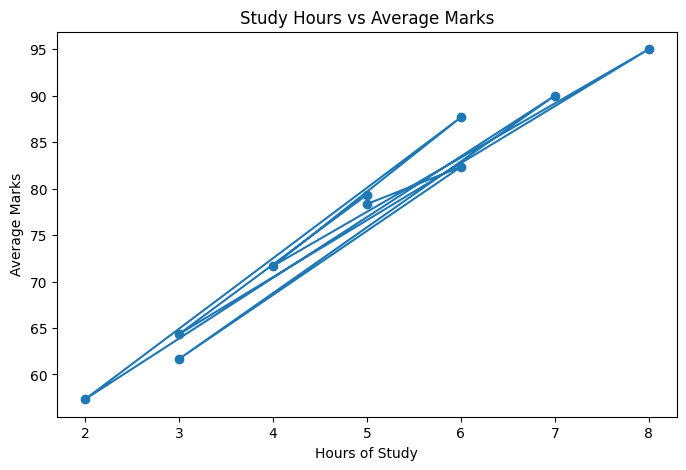

In [61]:
plt.figure(figsize=(8,5))
plt.plot(df['Hours_Study'], df['Average'], marker = 'o')
plt.title("Study Hours vs Average Marks")
plt.xlabel("Hours of Study")
plt.ylabel("Average Marks")
plt.show()


3. Pie Chart — Grade Distribution

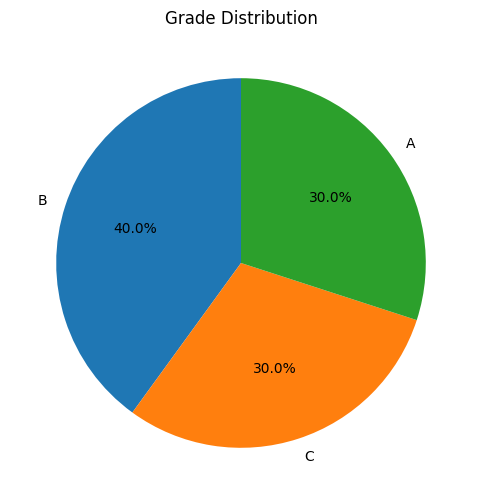

In [65]:
grade_counts = df["Grade"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Grade Distribution")
plt.show()

4. Histogram — Distribution of Total Marks

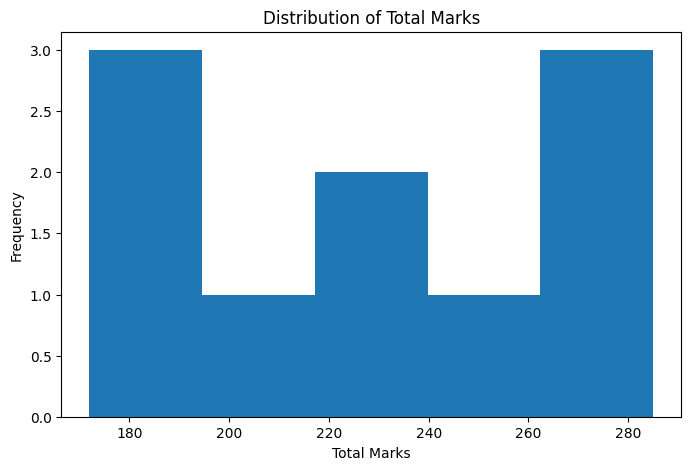

In [67]:
plt.figure(figsize=(8,5))
plt.hist(df["total"], bins=5)
plt.title("Distribution of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Frequency")
plt.show()

5. Scatter Plot — Study Hours vs Total Marks

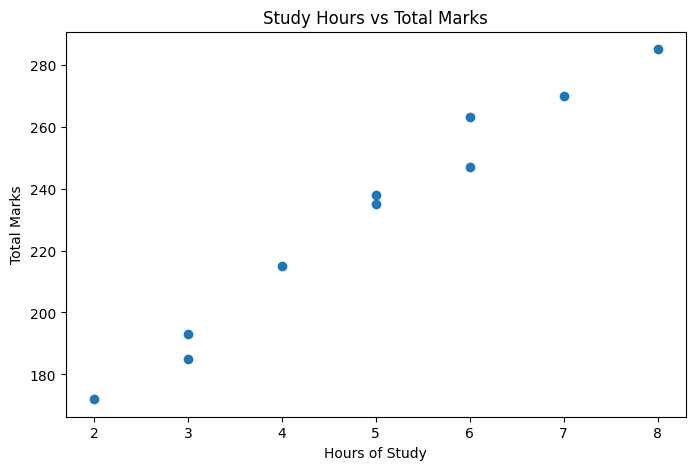

In [69]:
plt.figure(figsize=(8,5))
plt.scatter(df["Hours_Study"], df["total"])
plt.title("Study Hours vs Total Marks")
plt.xlabel("Hours of Study")
plt.ylabel("Total Marks")
plt.show()